# **Differences by gender**

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import seaborn as sns

In [ ]:


df24 = pd.read_csv('../data/GCSE results by sex - 2023-24.csv', header=1)
df23 = pd.read_csv('../data/GCSE results by sex - 2022-23.csv', header=1)
df22 = pd.read_csv('../data/GCSE results by sex - 2021-22.csv', header=1)
df19 = pd.read_csv('../data/GCSE results by sex - 2018-19.csv', header=1)
df18 = pd.read_csv('../data/GCSE results by sex - 2017-18.csv', header=1)
df17 = pd.read_csv('../data/GCSE results by sex - 2016-17.csv', header=1)


def clean(df):

  new_column_names = [
      'region_id',
      'region_name',
      'all_total_pupils',
      'all_attainment_8_score',
      'all_progress_8_score',
      'all_entered_english_maths',
      'all_achieving_grade_5_or_above_eng_math',
      'all_achieving_grade_4_or_above_eng_math',
      'boys_total_pupils',
      'boys_attainment_8_score',
      'boys_progress_8_score',
      'boys_entered_components',
      'boys_achieving_grade_5_or_above_overall',
      'boys_achieving_grade_4_or_above_overall',
      'girls_total_pupils',
      'girls_attainment_8_score',
      'girls_progress_8_score',
      'girls_entered_components',
      'girls_achieving_grade_5_or_above_overall',
      'girls_achieving_grade_4_or_above_overall'
  ]

  df.columns = new_column_names
  df_cleaned = df.dropna(how='all')
  df_cleaned = df_cleaned.dropna(subset=['region_name'])
  df_cleaned = df_cleaned.dropna(subset=['all_total_pupils'])

  for col in ['all_total_pupils', 'boys_total_pupils', 'girls_total_pupils']:
      df_cleaned[col] = df_cleaned[col].str.replace(',', '', regex=False).astype(int)

  for col in ['all_progress_8_score', 'boys_progress_8_score', 'girls_progress_8_score']:
      df_cleaned[col] = df_cleaned[col].astype(float)

  proportional_cols = [
      'boys_entered_components',
      'boys_achieving_grade_5_or_above_overall',
      'boys_achieving_grade_4_or_above_overall',
      'girls_entered_components',
      'girls_achieving_grade_5_or_above_overall',
      'girls_achieving_grade_4_or_above_overall'
  ]
  for col in proportional_cols:
      df_cleaned[col] = df_cleaned[col].astype(float)

  remove = [
      'South East', 'South West', 'England',
      'London', 'West Midlands', 'East Midlands',
      'Yorkshire and the Humber', 'North West',
      'North East', 'Inner London', 'Outer London',
      'East of England'
  ]
  df_cleaned = df_cleaned[~df_cleaned['region_name'].isin(remove)]

  return df_cleaned

In [56]:
df_24 = clean(df24)
df_23 = clean(df23)
df_22 = clean(df22)
df_19 = clean(df19)
df_18 = clean(df18)
df_17 = clean(df17)

df_24['Year'] = 2024
df_23['Year'] = 2023
df_22['Year'] = 2022
df_19['Year'] = 2019
df_18['Year'] = 2018
df_17['Year'] = 2017

df_cleaned = pd.concat([df_24, df_23, df_22, df_19, df_18, df_17], ignore_index=True)

In [57]:
df_cleaned

,region_id,region_name,all_total_pupils,all_attainment_8_score,all_progress_8_score,all_entered_english_maths,all_achieving_grade_5_or_above_eng_math,all_achieving_grade_4_or_above_eng_math,boys_total_pupils,boys_attainment_8_score,...,boys_entered_components,boys_achieving_grade_5_or_above_overall,boys_achieving_grade_4_or_above_overall,girls_total_pupils,girls_attainment_8_score,girls_progress_8_score,girls_entered_components,girls_achieving_grade_5_or_above_overall,girls_achieving_grade_4_or_above_overall,Year
0,E09000007,Camden,1605,47.9,-0.14,95.3,50.7,67.3,743,43.4,...,93.7,45.6,63.0,862,51.8,0.10,96.6,55.0,71.0,2024
1,E09000012,Hackney,2468,51.2,0.51,97.0,53.5,72.1,1169,50.1,...,96.4,53.6,70.3,1299,52.1,0.58,97.5,53.4,73.7,2024
2,E09000013,Hammersmith and Fulham,1528,55.9,0.52,95.2,64.4,79.2,759,53.2,...,93.3,61.4,76.2,769,58.6,0.64,97.1,67.4,82.2,2024
3,E09000014,Haringey,2713,48.1,0.30,95.8,49.6,67.1,1394,45.6,...,95.0,47.1,64.4,1319,50.8,0.48,96.7,52.2,70.0,2024
4,E09000019,Islington,1450,48.0,0.15,94.8,51.3,67.0,783,47.3,...,94.0,51.2,67.0,667,48.8,0.11,95.8,51.4,66.9,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,E09000030,Tower Hamlets,2623,47.2,0.25,95.7,44.3,65.2,1303,44.1,...,95.2,41.7,62.4,1320,50.3,0.54,96.3,47.0,68.0,2017
194,E09000031,Waltham Forest,2486,45.5,0.14,96.7,41.4,63.1,1254,43.0,...,96.0,39.9,62.4,1232,47.9,0.38,97.4,43.0,63.8,2017
195,E09000032,Wandsworth,1695,49.5,0.21,95.9,50.6,70.9,925,48.2,...,95.6,48.6,69.8,770,51.1,0.31,96.4,52.9,72.1,2017
196,E09000033,Westminster,1535,52.6,0.47,98.0,55.4,74.7,727,47.7,...,96.6,49.7,67.7,808,57.0,0.76,99.3,60.5,80.9,2017


In [58]:
display(df_cleaned['girls_progress_8_score'].describe())

df_cleaned['girls_progress_8_score'] = (df_cleaned['girls_progress_8_score'] / df_cleaned['girls_attainment_8_score']) + 100
df_cleaned['boys_progress_8_score'] = (df_cleaned['boys_progress_8_score'] / df_cleaned['boys_attainment_8_score']) + 100

display(df_cleaned['girls_progress_8_score'].describe())

count    198.000000
mean       0.420455
std        0.230152
min       -0.080000
25%        0.232500
50%        0.440000
75%        0.610000
max        0.840000
Name: girls_progress_8_score, dtype: float64

count    198.000000
mean     100.007798
std        0.004057
min       99.998507
25%      100.004709
50%      100.008263
75%      100.011047
max      100.015527
Name: girls_progress_8_score, dtype: float64

In [59]:
# 4. Calculate gender difference (Girls - Boys) and gender ratio (Girls / Boys)
# Attainment 8 Score
df_cleaned['gender_diff_attainment_8'] = df_cleaned['girls_attainment_8_score'] - df_cleaned['boys_attainment_8_score']
df_cleaned['gender_ratio_attainment_8'] = df_cleaned['girls_attainment_8_score'] / df_cleaned['boys_attainment_8_score']

# df_cleaned['girls_progress_8_score'] = (df_cleaned['girls_progress_8_score'] / df_cleaned['girls_attainment_8_score']) + 100
# df_cleaned['boys_progress_8_score'] = (df_cleaned['boys_progress_8_score'] / df_cleaned['boys_attainment_8_score']) + 100

# Progress 8 Score
df_cleaned['gender_diff_progress_8'] = df_cleaned['girls_progress_8_score'] - df_cleaned['boys_progress_8_score']
df_cleaned['gender_ratio_progress_8'] = df_cleaned['girls_progress_8_score'] / df_cleaned['boys_progress_8_score']

# Achieving Grade 5 or above (overall)
df_cleaned['gender_diff_achieving_5_plus'] = df_cleaned['girls_achieving_grade_5_or_above_overall'] - df_cleaned['boys_achieving_grade_5_or_above_overall']
df_cleaned['gender_ratio_achieving_5_plus'] = df_cleaned['girls_achieving_grade_5_or_above_overall'] / df_cleaned['boys_achieving_grade_5_or_above_overall']

# Achieving Grade 4 or above (overall)
df_cleaned['gender_diff_achieving_4_plus'] = df_cleaned['girls_achieving_grade_4_or_above_overall'] - df_cleaned['boys_achieving_grade_4_or_above_overall']
df_cleaned['gender_ratio_achieving_4_plus'] = df_cleaned['girls_achieving_grade_4_or_above_overall'] / df_cleaned['boys_achieving_grade_4_or_above_overall']


df_tower_hamlets = df_cleaned[df_cleaned['region_name'] == 'Tower Hamlets'].copy()
df_other_regions = df_cleaned[df_cleaned['region_name'] != 'Tower Hamlets'].copy()

In [60]:
# display(df_other_regions['gender_diff_achieving_5_plus'])
# df_tower_hamlets['gender_diff_achieving_5_plus']

df_cleaned.describe()

,all_total_pupils,all_attainment_8_score,all_progress_8_score,boys_total_pupils,boys_attainment_8_score,boys_progress_8_score,boys_entered_components,boys_achieving_grade_5_or_above_overall,boys_achieving_grade_4_or_above_overall,girls_total_pupils,...,girls_achieving_grade_4_or_above_overall,Year,gender_diff_attainment_8,gender_ratio_attainment_8,gender_diff_progress_8,gender_ratio_progress_8,gender_diff_achieving_5_plus,gender_ratio_achieving_5_plus,gender_diff_achieving_4_plus,gender_ratio_achieving_4_plus
count,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,...,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000
mean,4392.575758,50.343939,0.238535,2231.262626,47.870202,100.000861,95.730808,49.521717,67.832323,2161.313131,...,72.869697,2020.500000,4.950000,1.105704,0.006938,1.000069,5.040404,1.109635,5.037374,1.077332
std,10206.472904,3.872569,0.226837,5216.045676,4.216113,0.005236,1.331504,8.234975,6.590269,4991.014970,...,5.606169,2.636622,1.802529,0.042066,0.003337,0.000033,3.485792,0.078847,3.188274,0.050896
min,718.000000,43.700000,-0.280000,405.000000,40.400000,99.987871,90.500000,33.400000,54.900000,306.000000,...,60.400000,2017.000000,-1.700000,0.967495,-0.001551,0.999984,-9.800000,0.840391,-8.300000,0.892626
25%,1955.500000,47.200000,0.050000,934.000000,44.425000,99.996896,94.900000,43.125000,63.000000,943.500000,...,68.825000,2018.000000,4.100000,1.082141,0.004465,1.000045,3.300000,1.063211,3.225000,1.047928
50%,2720.000000,49.800000,0.240000,1374.500000,47.250000,100.001094,95.900000,47.900000,67.100000,1327.500000,...,72.500000,2020.500000,5.100000,1.106841,0.007072,1.000071,5.050000,1.104591,5.100000,1.075877
75%,3273.000000,52.675000,0.450000,1674.250000,50.475000,100.005048,96.700000,55.400000,72.300000,1601.500000,...,76.475000,2023.000000,5.900000,1.131057,0.009155,1.000092,6.800000,1.153869,6.775000,1.103678
max,65738.000000,61.000000,0.650000,33786.000000,59.200000,100.012574,98.000000,69.300000,83.100000,31952.000000,...,86.200000,2024.000000,10.400000,1.247619,0.018375,1.000184,17.600000,1.399093,16.000000,1.280702


In [61]:
gender_gap_metrics = [
    'gender_diff_attainment_8',
    'gender_ratio_attainment_8',
    'gender_diff_progress_8',
    'gender_ratio_progress_8',
    'gender_diff_achieving_5_plus',
    'gender_ratio_achieving_5_plus',
    'gender_diff_achieving_4_plus',
    'gender_ratio_achieving_4_plus'
]

z_scores = {}

for metric in gender_gap_metrics:
    mean_other_regions = df_other_regions[metric].mean()
    std_other_regions = df_other_regions[metric].std()

    # Get Tower Hamlets' value for the metric
    tower_hamlets_value = df_tower_hamlets[metric].iloc[0]

    # Calculate Z-score
    # Handle cases where std_other_regions might be 0 to avoid division by zero
    if std_other_regions != 0:
        z_score = (tower_hamlets_value - mean_other_regions) / std_other_regions
    else:
        z_score = 0 if (tower_hamlets_value - mean_other_regions) == 0 else float('inf') # Or handle as NaN/specific value

    z_scores[metric] = {
        'tower_hamlets_value': tower_hamlets_value,
        'mean_other_regions': mean_other_regions,
        'std_other_regions': std_other_regions,
        'z_score': z_score
    }

z_scores


{'gender_diff_attainment_8': {'tower_hamlets_value': np.float64(5.899999999999999),
  'mean_other_regions': np.float64(4.929687500000001),
  'std_other_regions': np.float64(1.8243851165981706),
  'z_score': np.float64(0.5318572768283077)},
 'gender_ratio_attainment_8': {'tower_hamlets_value': np.float64(1.1299559471365639),
  'mean_other_regions': np.float64(1.105137578664076),
  'std_other_regions': np.float64(0.04251645778761341),
  'z_score': np.float64(0.5837355641541322)},
 'gender_diff_progress_8': {'tower_hamlets_value': np.float64(0.005068226120855002),
  'mean_other_regions': np.float64(0.0068942426947578754),
  'std_other_regions': np.float64(0.0033546183864617556),
  'z_score': np.float64(-0.5443291497095869)},
 'gender_ratio_progress_8': {'tower_hamlets_value': np.float64(1.0000506822612085),
  'mean_other_regions': np.float64(1.0000689429188985),
  'std_other_regions': np.float64(3.3548550425523124e-05),
  'z_score': np.float64(-0.5443054158327463)},
 'gender_diff_achievin

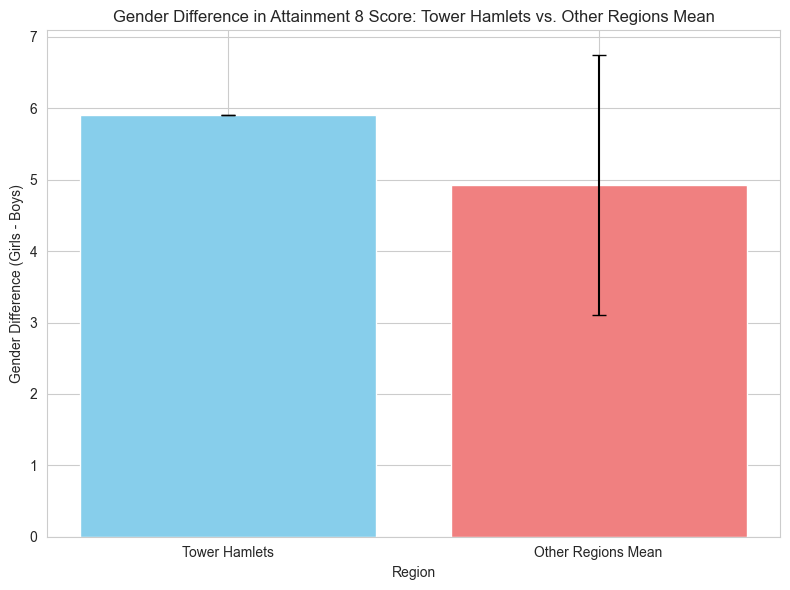

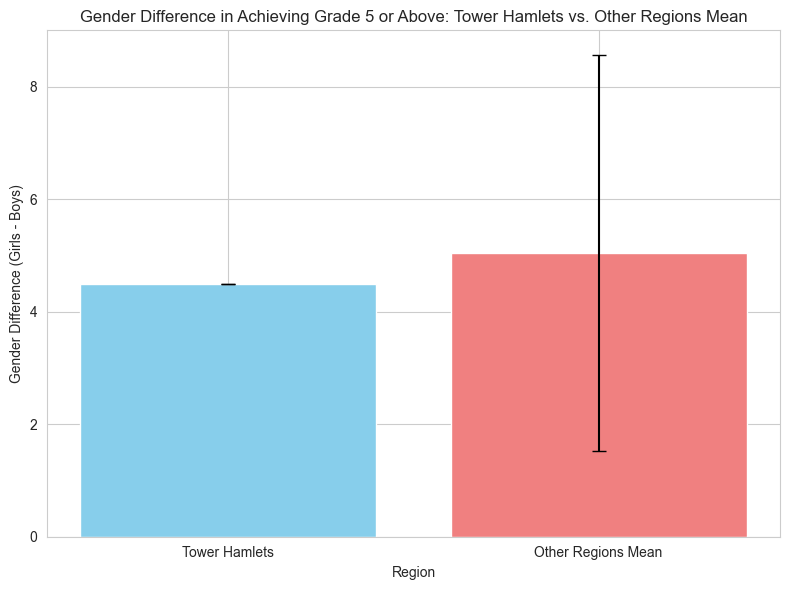

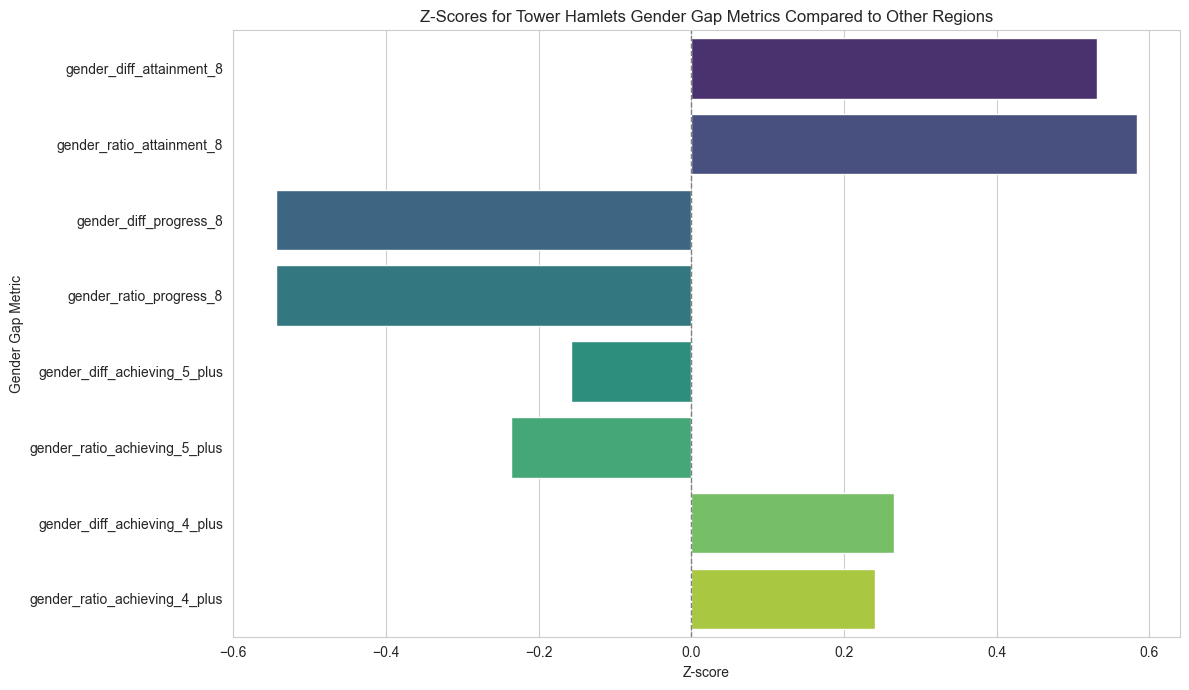

In [62]:
# Set a style for the plots
sns.set_style("whitegrid")

# --- Plot 1: Gender Difference in Attainment 8 Score ---
plt.figure(figsize=(8, 6))

# Data for plotting
attainment_8_th = df_tower_hamlets['gender_diff_attainment_8'].iloc[0]
attainment_8_mean_others = df_other_regions['gender_diff_attainment_8'].mean()
attainment_8_std_others = df_other_regions['gender_diff_attainment_8'].std()

regions = ['Tower Hamlets', 'Other Regions Mean']
values = [attainment_8_th, attainment_8_mean_others]
errors = [0, attainment_8_std_others] # No error bar for single value of Tower Hamlets

plt.bar(regions, values, yerr=errors, capsize=5, color=['skyblue', 'lightcoral'])
plt.title('Gender Difference in Attainment 8 Score: Tower Hamlets vs. Other Regions Mean')
plt.xlabel('Region')
plt.ylabel('Gender Difference (Girls - Boys)')
plt.tight_layout()
plt.show()

# --- Plot 2: Gender Difference in Achieving Grade 5+ ---
plt.figure(figsize=(8, 6))

# Data for plotting
achieving_5_plus_th = df_tower_hamlets['gender_diff_achieving_5_plus'].iloc[0]
achieving_5_plus_mean_others = df_other_regions['gender_diff_achieving_5_plus'].mean()
achieving_5_plus_std_others = df_other_regions['gender_diff_achieving_5_plus'].std()

regions = ['Tower Hamlets', 'Other Regions Mean']
values = [achieving_5_plus_th, achieving_5_plus_mean_others]
errors = [0, achieving_5_plus_std_others]

plt.bar(regions, values, yerr=errors, capsize=5, color=['skyblue', 'lightcoral'])
plt.title('Gender Difference in Achieving Grade 5 or Above: Tower Hamlets vs. Other Regions Mean')
plt.xlabel('Region')
plt.ylabel('Gender Difference (Girls - Boys)')
plt.tight_layout()
plt.show()

# --- Plot 3: Z-Scores for all Gender Gap Metrics ---

# Extract z-scores and metric names, handling potential 'inf' values gracefully
z_score_names = []
z_score_values = []

for metric, data in z_scores.items():
    if data['z_score'] not in [float('inf'), float('-inf')]: # Exclude infinite z-scores for plotting clarity
        z_score_names.append(metric)
        z_score_values.append(data['z_score'])

plt.figure(figsize=(12, 7))
sns.barplot(x=z_score_values, y=z_score_names, palette='viridis', hue=z_score_names, legend=False)
plt.axvline(0, color='gray', linestyle='--', linewidth=1) # Horizontal line at y=0 is now vertical for bar plot
plt.title('Z-Scores for Tower Hamlets Gender Gap Metrics Compared to Other Regions')
plt.xlabel('Z-score')
plt.ylabel('Gender Gap Metric')
plt.tight_layout()
plt.show()

# **Differences by SEN**

In [63]:
df_24 = pd.read_csv('../Results/GCSE results by SEN.xlsx - 2023-24.csv', header=None)
df_23 = pd.read_csv('../Results/GCSE results by SEN.xlsx - 2022-23.csv', header=None)


def clean(df_sen_raw):
  header_row0 = df_sen_raw.iloc[0]
  header_row1 = df_sen_raw.iloc[1]

  new_column_names = []

  # Define the structure of the data blocks based on observation
  # Each main group (Total, Boys, Girls) has 3 metrics, and each metric has 4 SEN categories.
  # So, each main group block is 3 * 4 = 12 columns wide.

  group_definitions = [
      {'name': 'total', 'start_index': 2},    # 'Total' group starts at index 2
      {'name': 'boys', 'start_index': 14},   # 'Boys' group starts at index 14
      {'name': 'girls', 'start_index': 26}  # 'Girls' group starts at index 26
  ]

  metric_short_names = [
      'num_pupils_ks4',
      'attainment_8',
      'progress_8'
  ]

  sen_categories = [
      'total',        # This is for the 'Total' SEN category within a metric
      'no_sen',
      'sen_state_ehc',
      'sen_supp'
  ]

  for i in range(len(df_sen_raw.columns)):
      # Handle the first two columns (region_id, region_name)
      if i == 0:
          new_column_names.append('region_id')
          continue
      if i == 1:
          new_column_names.append('region_name')
          continue

      column_named = False
      for group_def in group_definitions:
          group_name = group_def['name']
          group_start = group_def['start_index']

          # Check if the current column 'i' falls within this group's block
          if i >= group_start and i < group_start + (len(metric_short_names) * len(sen_categories)):
              # Calculate offset within this group's block
              offset_in_group = i - group_start

              # Determine the metric type (num_pupils_ks4, attainment_8, progress_8)
              metric_idx = offset_in_group // len(sen_categories)
              metric_name = metric_short_names[metric_idx]

              # Determine the SEN category within this metric
              sen_cat_idx = offset_in_group % len(sen_categories)
              sen_cat_name = sen_categories[sen_cat_idx]

              new_column_names.append(f"{group_name}_{metric_name}_{sen_cat_name}")
              column_named = True
              break # Found the correct group and named the column, move to next 'i'

      if not column_named:
          # Fallback for any columns that don't fit the defined pattern (should ideally not happen with correct definitions)
          new_column_names.append(f"unhandled_col_{i}")

  # Assign new column names and drop the header rows (first four rows of the raw data, indices 0, 1, 2, 3)
  df_sen = df_sen_raw.copy()
  df_sen.columns = new_column_names
  df_sen = df_sen.drop([0, 1, 2, 3]).reset_index(drop=True)
  return df_sen

In [64]:
df_23 = clean(df_23)
df_24 = clean(df_24)

df_24['Year'] = 2024
df_23['Year'] = 2023

df_sen_cleaned = pd.concat([df_24, df_23], ignore_index=True)

display(df_sen_cleaned)

,region_id,region_name,total_num_pupils_ks4_total,total_num_pupils_ks4_no_sen,total_num_pupils_ks4_sen_state_ehc,total_num_pupils_ks4_sen_supp,total_attainment_8_total,total_attainment_8_no_sen,total_attainment_8_sen_state_ehc,total_attainment_8_sen_supp,...,girls_num_pupils_ks4_sen_supp,girls_attainment_8_total,girls_attainment_8_no_sen,girls_attainment_8_sen_state_ehc,girls_attainment_8_sen_supp,girls_progress_8_total,girls_progress_8_no_sen,girls_progress_8_sen_state_ehc,girls_progress_8_sen_supp,Year
0,NaN,Camden,"1,605","1,267",89,249,47.9,52.2,18.9,36.3,...,129,51.8,55.4,17.3,37.6,0.10,0.32,-1.26,-0.78,2024
1,NaN,Hackney,"2,468","1,968",123,377,51.2,55.4,20.1,39.2,...,174,52.1,55.2,22.2,39.1,0.58,0.72,-0.54,0.00,2024
2,NaN,Hammersmith and Fulham,"1,528","1,236",103,189,55.9,61.1,15.1,44.3,...,90,58.6,61.8,18.5,49.2,0.64,0.75,-1.04,0.43,2024
3,NaN,Haringey,"2,713","2,214",138,361,48.1,51.1,17.9,41.2,...,142,50.8,52.7,15.6,46.0,0.48,0.53,-0.51,0.42,2024
4,NaN,Islington,"1,450","1,098",97,255,48.0,53.2,13.3,38.6,...,111,48.8,52.9,6.5,36.5,0.11,0.27,-1.50,-0.37,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,NaN,Merton,"1,711","1,310",112,289,52.2,57.4,22.1,40.2,...,124,53.7,57.9,18.1,41.6,0.66,0.79,-1.06,0.38,2023
61,NaN,Redbridge,"3,949","3,420",157,371,54.6,57.7,19.3,41.1,...,160,56.6,58.9,23.2,40.7,0.62,0.70,-0.45,0.04,2023
62,NaN,Richmond upon Thames,"1,891","1,541",106,244,55.9,60.3,22.3,42.9,...,97,58.7,61.9,21.5,45.1,0.53,0.64,-0.60,0.06,2023
63,NaN,Sutton,"3,278","2,880",130,267,59.9,63.5,16.2,42.9,...,147,61.1,63.5,26.8,43.5,0.61,0.69,0.04,-0.13,2023


In [65]:
pupil_count_cols = [
    'total_num_pupils_ks4_total', 'total_num_pupils_ks4_no_sen', 'total_num_pupils_ks4_sen_state_ehc', 'total_num_pupils_ks4_sen_supp',
    'boys_num_pupils_ks4_total', 'boys_num_pupils_ks4_no_sen', 'boys_num_pupils_ks4_sen_state_ehc', 'boys_num_pupils_ks4_sen_supp',
    'girls_num_pupils_ks4_total', 'girls_num_pupils_ks4_no_sen', 'girls_num_pupils_ks4_sen_state_ehc', 'girls_num_pupils_ks4_sen_supp'
]

attainment_progress_cols = [
    'total_attainment_8_total', 'total_attainment_8_no_sen', 'total_attainment_8_sen_state_ehc', 'total_attainment_8_sen_supp',
    'total_progress_8_total', 'total_progress_8_no_sen', 'total_progress_8_sen_state_ehc', 'total_progress_8_sen_supp',
    'boys_attainment_8_total', 'boys_attainment_8_no_sen', 'boys_attainment_8_sen_state_ehc', 'boys_attainment_8_sen_supp',
    'boys_progress_8_total', 'boys_progress_8_no_sen', 'boys_progress_8_sen_state_ehc', 'boys_progress_8_sen_supp',
    'girls_attainment_8_total', 'girls_attainment_8_no_sen', 'girls_attainment_8_sen_state_ehc', 'girls_attainment_8_sen_supp',
    'girls_progress_8_total', 'girls_progress_8_no_sen', 'girls_progress_8_sen_state_ehc', 'girls_progress_8_sen_supp'
]

# Convert pupil count columns to integer, handling commas and potential errors
for col in pupil_count_cols:
    df_sen_cleaned[col] = pd.to_numeric(df_sen_cleaned[col].astype(str).str.replace(',', '', regex=False), errors='coerce')
    df_sen_cleaned[col] = df_sen_cleaned[col].fillna(0).astype(int)

# Convert attainment/progress score columns to float, handling potential errors
for col in attainment_progress_cols:
    df_sen_cleaned[col] = pd.to_numeric(df_sen_cleaned[col], errors='coerce')

# Remove aggregated regions similar to the previous notebook
remove_regions = [
    'South East', 'South West', 'England', 'London', 'West Midlands',
    'East Midlands', 'Yorkshire and the Humber', 'North West', 'North East',
    'Inner London', 'Outer London', 'East of England'
]
df_sen_cleaned = df_sen_cleaned[~df_sen_cleaned['region_name'].isin(remove_regions)]

In [66]:
sen_gap_metrics = [
    'attainment_8',
    'progress_8'
]

sen_comparison_groups = [
    {'sen_category': 'sen_state_ehc', 'comparison_name': 'no_sen_vs_sen_state_ehc'},
    {'sen_category': 'sen_supp', 'comparison_name': 'no_sen_vs_sen_supp'}
]

gender_groups = ['total', 'boys', 'girls']

for gender in gender_groups:
    for metric in sen_gap_metrics:
        for comp_group in sen_comparison_groups:
            sen_cat = comp_group['sen_category']
            comp_name = comp_group['comparison_name']

            no_sen_col = f'{gender}_{metric}_no_sen'
            sen_col = f'{gender}_{metric}_{sen_cat}'

            # Calculate difference (No SEN - SEN)
            diff_col_name = f'{gender}_diff_{metric}_{comp_name}'
            df_sen_cleaned[diff_col_name] = df_sen_cleaned[no_sen_col] - df_sen_cleaned[sen_col]

            # Calculate ratio (No SEN / SEN)
            ratio_col_name = f'{gender}_ratio_{metric}_{comp_name}'
            # Add a small epsilon to avoid division by zero if any SEN score is 0
            df_sen_cleaned[ratio_col_name] = df_sen_cleaned[no_sen_col] / (df_sen_cleaned[sen_col] + 1e-6)

# Separate Tower Hamlets from other regions
df_sen_tower_hamlets = df_sen_cleaned[df_sen_cleaned['region_name'] == 'Tower Hamlets'].copy()
df_sen_other_regions = df_sen_cleaned[df_sen_cleaned['region_name'] != 'Tower Hamlets'].copy()

In [67]:
sen_gap_metrics_for_z_score = []

# Populate the list with all generated diff and ratio columns
for gender in gender_groups:
    for metric in sen_gap_metrics:
        for comp_group in sen_comparison_groups:
            comp_name = comp_group['comparison_name']
            sen_gap_metrics_for_z_score.append(f'{gender}_diff_{metric}_{comp_name}')
            sen_gap_metrics_for_z_score.append(f'{gender}_ratio_{metric}_{comp_name}')

z_scores_sen = {}

for metric in sen_gap_metrics_for_z_score:
    # Ensure the metric exists in the dataframe before proceeding
    if metric not in df_sen_other_regions.columns or metric not in df_sen_tower_hamlets.columns:
        print(f"Warning: Metric '{metric}' not found in one of the dataframes. Skipping.")
        continue

    mean_other_regions = df_sen_other_regions[metric].mean()
    std_other_regions = df_sen_other_regions[metric].std()

    # Get Tower Hamlets' value for the metric
    # Check if df_sen_tower_hamlets is empty for the current metric
    if not df_sen_tower_hamlets[metric].empty:
        tower_hamlets_value = df_sen_tower_hamlets[metric].iloc[0]
    else:
        tower_hamlets_value = np.nan # Or any other appropriate value

    # Calculate Z-score
    # Handle cases where std_other_regions might be 0 to avoid division by zero
    if std_other_regions != 0:
        z_score = (tower_hamlets_value - mean_other_regions) / std_other_regions
    else:
        z_score = 0 if (tower_hamlets_value - mean_other_regions) == 0 else float('inf') # Or handle as NaN/specific value

    z_scores_sen[metric] = {
        'tower_hamlets_value': tower_hamlets_value,
        'mean_other_regions': mean_other_regions,
        'std_other_regions': std_other_regions,
        'z_score': z_score
    }


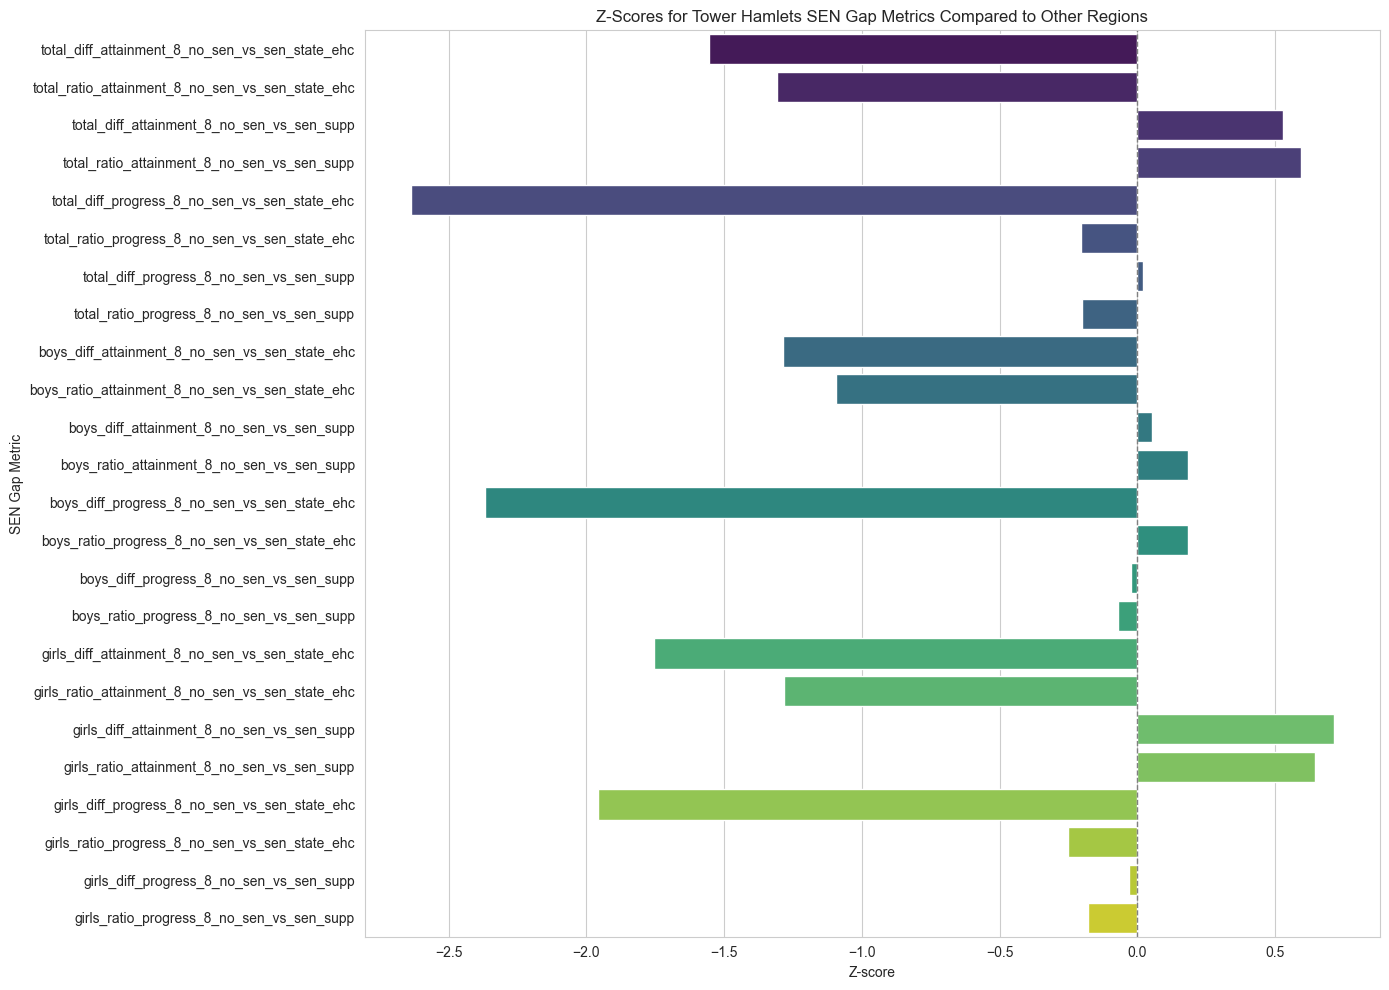

In [68]:
sns.set_style("whitegrid")

# Prepare data for plotting Z-scores
z_score_names_sen = []
z_score_values_sen = []

for metric, data in z_scores_sen.items():
    if data['z_score'] not in [float('inf'), float('-inf')] and not pd.isna(data['z_score']):
        z_score_names_sen.append(metric)
        z_score_values_sen.append(data['z_score'])

# Create the bar plot for Z-scores
plt.figure(figsize=(14, 10))
sns.barplot(x=z_score_values_sen, y=z_score_names_sen, palette='viridis', hue=z_score_names_sen, legend=False)
plt.axvline(0, color='gray', linestyle='--', linewidth=1) # Vertical line at x=0
plt.title('Z-Scores for Tower Hamlets SEN Gap Metrics Compared to Other Regions')
plt.xlabel('Z-score')
plt.ylabel('SEN Gap Metric')
plt.tight_layout()
plt.show()


# **Subgroups within TH**

In [69]:
import numpy as np
import pandas as pd
import re


df24 = pd.read_csv('../Results/TH results 2024-25.csv')
df23 = pd.read_csv('../Results/TH results 2023-24.csv')
df22 = pd.read_csv('../Results/TH results 2022-23.csv')
df21 = pd.read_csv('../Results/TH results 2021-22.csv')

df_raw = pd.concat([df24, df23, df22, df21], ignore_index=True)


df_cleaned = df_raw[['SCHNAME', 'TPUP', 'BPUP', 'GPUP', 'ATT8SCR', 'SENE4', 'SENK4', 'SEN_ALL4', 'ATT8SCR_GIRLS', 'ATT8SCR_BOYS', 'P8MEA']].copy()
# Removing very small schools, for better accuracy
df_cleaned = df_cleaned[df_cleaned['TPUP'] > 10]
df_cleaned.replace(['NE', 'SUPP', 'NP'], np.nan, inplace=True)
df_cleaned.dropna(subset=['SCHNAME'], inplace=True)

new_column_names = {
    'SCHNAME': 'school_name',
    'TPUP': 'total_pupils',
    'BPUP': 'boys_pupils',
    'GPUP': 'girls_pupils',
    'ATT8SCR': 'attainment_8_score_all',
    'SENE4': 'sen_ehc_plan_pupils',
    'SENK4': 'sen_support_pupils',
    'SEN_ALL4': 'sen_total_pupils',
    'ATT8SCR_GIRLS': 'attainment_8_score_girls',
    'ATT8SCR_BOYS': 'attainment_8_score_boys',
    'P8MEA': 'progress_8_score'
}

df_cleaned.rename(columns=new_column_names, inplace=True)

pupil_cols = ['total_pupils', 'boys_pupils', 'girls_pupils']
for col in pupil_cols:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce').fillna(0).astype(int)

attainment_sen_cols = [
    'attainment_8_score_all', 'sen_ehc_plan_pupils', 'sen_support_pupils', 'sen_total_pupils',
    'attainment_8_score_girls', 'attainment_8_score_boys'
]
for col in attainment_sen_cols:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

df_cleaned.dropna(subset=['attainment_8_score_all'], inplace=True)

df_cleaned.sort_values(by='attainment_8_score_all', inplace=True)

df_cleaned

,school_name,total_pupils,boys_pupils,girls_pupils,attainment_8_score_all,sen_ehc_plan_pupils,sen_support_pupils,sen_total_pupils,attainment_8_score_girls,attainment_8_score_boys,progress_8_score
125,Phoenix School,35,29,6,0.3,NaN,NaN,NaN,0.0,0.3,-1.91
59,Phoenix School,36,29,7,0.4,NaN,NaN,NaN,0.0,0.5,-1.6
77,Ian Mikardo School,12,12,0,2.8,NaN,NaN,NaN,NaN,2.8,-2.59
6,The Complete Works,60,40,20,4.9,NaN,NaN,NaN,5.3,4.8,NaN
9,Ian Mikardo School,11,11,0,5.7,NaN,NaN,NaN,NaN,5.7,NaN
...,...,...,...,...,...,...,...,...,...,...,...
75,Darul Hadis Latifiah,14,14,0,59.9,NaN,NaN,NaN,NaN,59.9,NaN
116,Madani Secondary Girls' School,41,0,41,60.7,NaN,NaN,NaN,60.7,NaN,NaN
80,London East Academy,28,28,0,63.4,NaN,NaN,NaN,NaN,63.4,NaN
44,Jamiatul Ummah School,27,27,0,67.7,NaN,NaN,NaN,NaN,67.7,NaN


In [70]:
from scipy import stats
import numpy as np

df_cleaned['gender_attainment_difference'] = df_cleaned['attainment_8_score_girls'] - df_cleaned['attainment_8_score_boys']
df_cleaned['sen_proportion'] = df_cleaned['sen_total_pupils'] / df_cleaned['total_pupils']
df_cleaned['attainment_8_z_scores'] = stats.zscore(df_cleaned['attainment_8_score_all'])

df_cleaned.info()


<class 'pandas.core.frame.DataFrame'>
Index: 106 entries, 125 to 108
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   school_name                   106 non-null    object 
 1   total_pupils                  106 non-null    int64  
 2   boys_pupils                   106 non-null    int64  
 3   girls_pupils                  106 non-null    int64  
 4   attainment_8_score_all        106 non-null    float64
 5   sen_ehc_plan_pupils           70 non-null     float64
 6   sen_support_pupils            70 non-null     float64
 7   sen_total_pupils              70 non-null     float64
 8   attainment_8_score_girls      77 non-null     float64
 9   attainment_8_score_boys       86 non-null     float64
 10  progress_8_score              59 non-null     object 
 11  gender_attainment_difference  63 non-null     float64
 12  sen_proportion                70 non-null     float64
 13  attainme

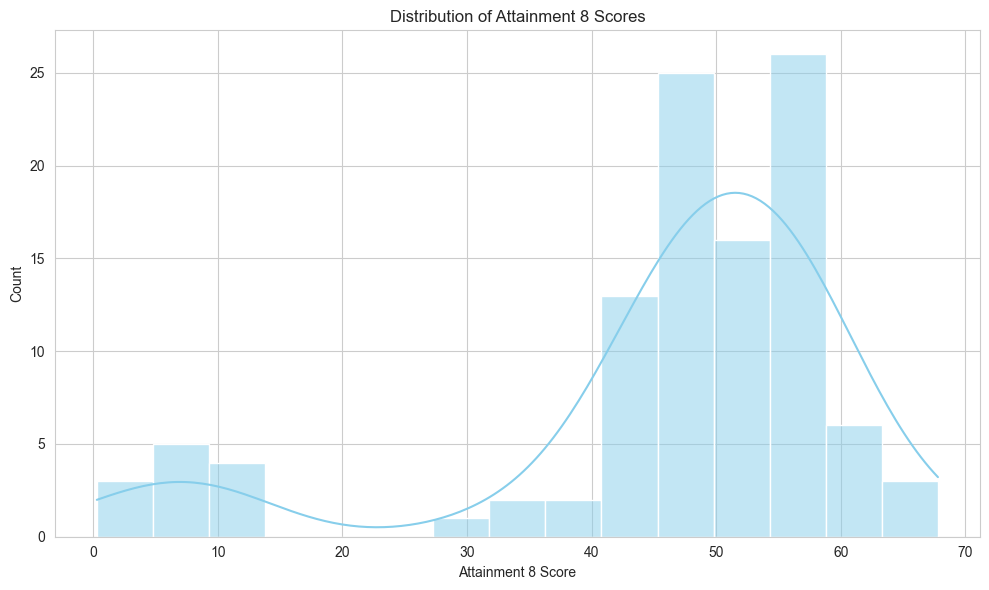

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['attainment_8_score_all'], kde=True, bins=15, color='skyblue')
plt.title('Distribution of Attainment 8 Scores')
plt.xlabel('Attainment 8 Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

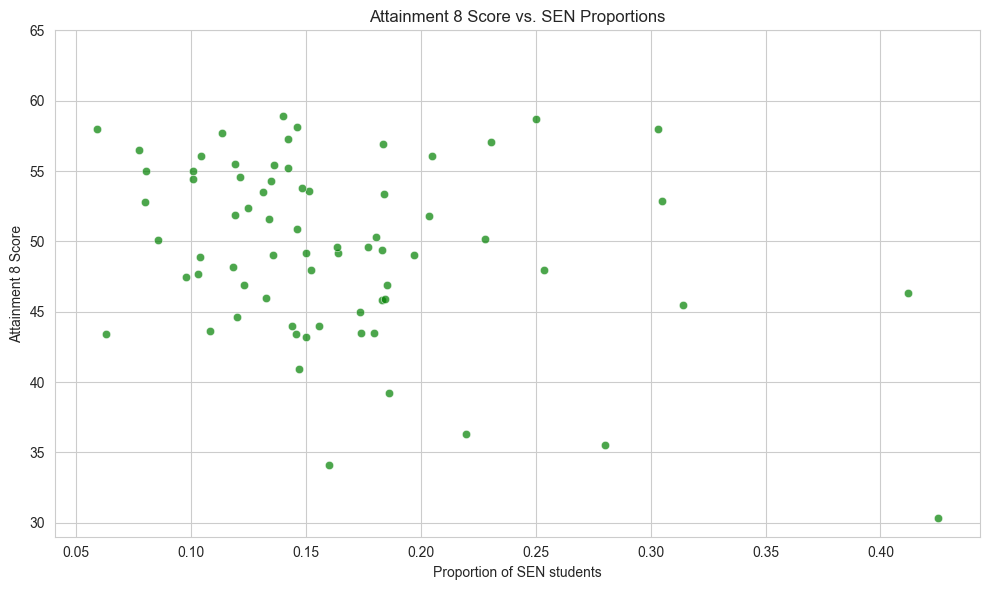

In [72]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='sen_proportion', y='attainment_8_score_all', data=df_cleaned, color='green', alpha=0.7)
plt.title('Attainment 8 Score vs. SEN Proportions')
plt.xlabel('Proportion of SEN students')
plt.ylabel('Attainment 8 Score')
plt.ylim(29, 65) # Setting the y-axis range
#plt.xlim(0, 1)
plt.tight_layout()
plt.show()

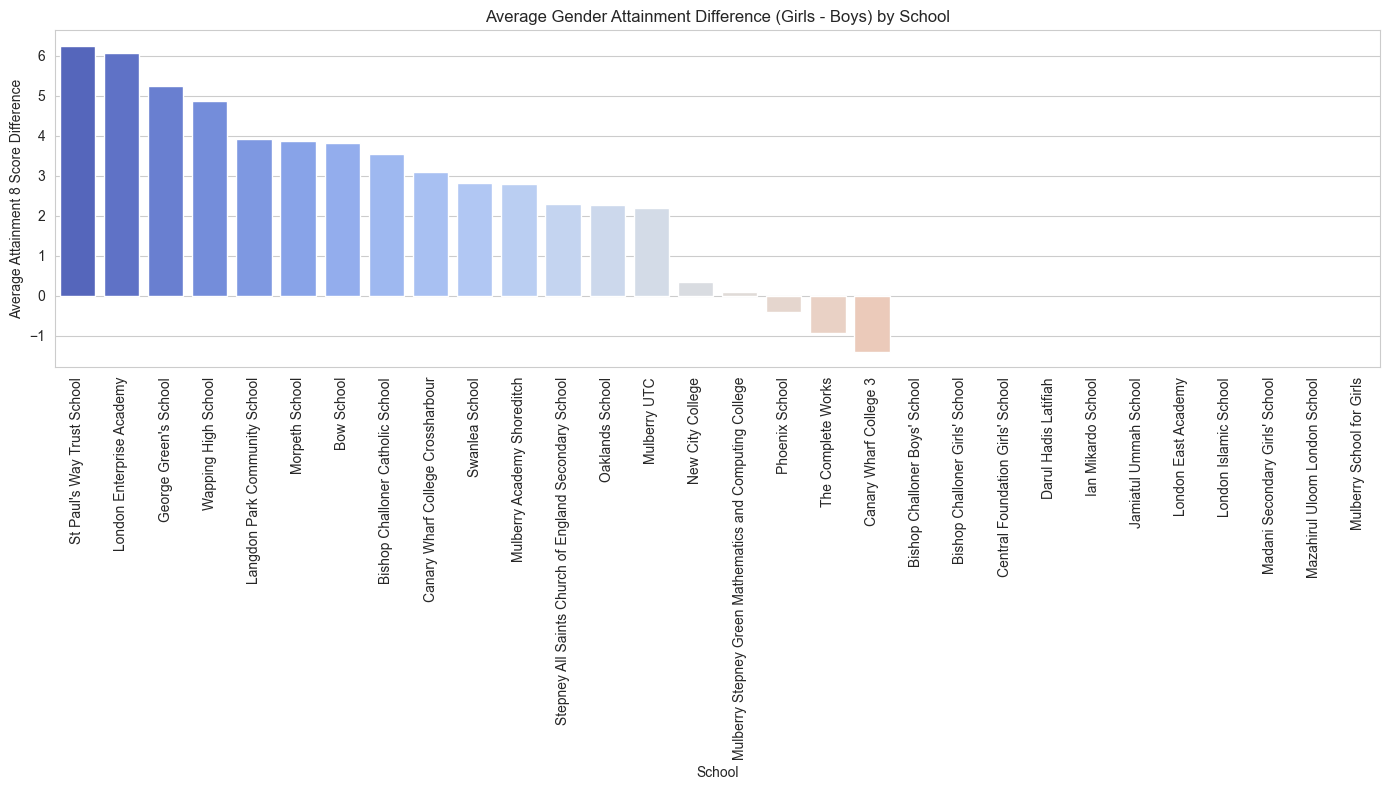

In [73]:
df_gender_diff = df_cleaned.groupby('school_name')['gender_attainment_difference'].mean().reset_index()
df_gender_diff = df_gender_diff.sort_values(by='gender_attainment_difference', ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(x='school_name', y='gender_attainment_difference', data=df_gender_diff, palette='coolwarm', hue='school_name', legend=False)
plt.title('Average Gender Attainment Difference (Girls - Boys) by School')
plt.xlabel('School')
plt.ylabel('Average Attainment 8 Score Difference')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()